# 55230316 汤雨润 - DroneVehicle 数据探索与基线评估报告

**任务**：无人机俯视 RGB 车辆检测 EDA + 基线模型评估

> 模型定义与训练代码见 `55230316_baseline_train.py`，本 Notebook 专注于数据分析与结果可视化。


In [ ]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from PIL import Image
import torch

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'DroneVehicle'
FIGURES_DIR  = NOTEBOOK_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Data set root directory: {DATASET_ROOT}")
print(f"Image Save Directory: {FIGURES_DIR}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")


数据集根目录：/home/tyr/datasets/DroneVehicle
图片保存目录：/home/tyr/ultralytics/figures
PyTorch 版本：2.10.0+cu128
CUDA 可用：True


## Part 1：数据集基本统计

In [ ]:
data_splits = {
    'train': DATASET_ROOT / 'train',
    'val':   DATASET_ROOT / 'val',
    'test':  DATASET_ROOT / 'test',
}

def count_files(path, ext):
    return sum(1 for _ in path.rglob(f'*{ext}')) if path.exists() else 0

rows = {}
for split, p in data_splits.items():
    img_dir = p / ('trainimg' if split == 'train' else f'{split}img')
    lbl_dir = p / ('trainlabel' if split == 'train' else f'{split}label')
    rows[split] = {
        'RGB image': count_files(img_dir, '.jpg'),
        'Annotation files': count_files(lbl_dir, '.xml'),
    }

df = pd.DataFrame(rows).T
print(df)
print(f"\nTotal number of images: {df['RGB image'].sum()}")


       RGB 图像   标注文件
train   17990  17990
val      1469   1469
test     8980   8980

总图像数：28439


## Part 2：标签解析与类别分析

In [ ]:
def parse_xml_annotation(xml_path):
    try:
        root = ET.parse(xml_path).getroot()
        size = root.find('size')
        W, H = int(size.find('width').text), int(size.find('height').text)
        objects = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            poly = obj.find('polygon')
            if poly is None:
                continue
            xs = [int(poly.find(f'x{i}').text) for i in range(1, 5)]
            ys = [int(poly.find(f'y{i}').text) for i in range(1, 5)]
            objects.append({
                'class': name,
                'bbox':  [min(xs), min(ys), max(xs), max(ys)],
                'area':  (max(xs)-min(xs)) * (max(ys)-min(ys)),
            })
        return {'image_width': W, 'image_height': H, 'objects': objects}
    except Exception:
        return None

sample = parse_xml_annotation(sorted((DATASET_ROOT/'train'/'trainlabel').glob('*.xml'))[0])
print(f"Image size: {sample['image_width']} x {sample['image_height']}")
print(f"Number of objects: {len(sample['objects'])}")
print(f"Example: {sample['objects'][0]}")


图像尺寸：840 x 712
目标数：9
示例：{'class': 'car', 'bbox': [254, 258, 279, 321], 'area': 1575}


In [ ]:
CLASS_NORMALIZE = {
    'car': 'car', 'truck': 'truck', 'bus': 'bus', 'van': 'van',
    'feright_car': 'truck', 'feright car': 'truck', 'feright': 'truck',
    'truvk': 'truck',
}

print("Parsing training set annotations (approximately 17990 files)...")
train_label_dir = DATASET_ROOT / 'train' / 'trainlabel'

raw_class_counts  = Counter()
norm_class_counts = Counter()
area_by_class     = defaultdict(list)
obj_per_image     = []

for xml_file in sorted(train_label_dir.glob('*.xml')):
    anno = parse_xml_annotation(xml_file)
    if anno is None:
        continue
    obj_per_image.append(len(anno['objects']))
    for obj in anno['objects']:
        raw_class_counts[obj['class']] += 1
        norm = CLASS_NORMALIZE.get(obj['class'])
        if norm:
            norm_class_counts[norm] += 1
            area_by_class[norm].append(obj['area'])

print(f"✓ Parsing completed, total {len(obj_per_image)} images")
print(f"\nOriginal class distribution:")
for k, v in raw_class_counts.most_common():
    print(f"  {k:15s}: {v:7d}")
print(f"\nNormalized class distribution (4 classes):")
for k, v in norm_class_counts.most_common():
    print(f"  {k:8s}: {v:7d}")


解析训练集标注（约 17990 个文件）...
✓ 解析完成，共 17990 张图像

原始类别分布：
  car            :  226974
  truck          :   13056
  bus            :    9988
  van            :    7208
  feright_car    :    5337
  feright car    :    2721
  feright        :       1
  *              :       1
  truvk          :       1

标准化后 4 类分布：
  car     :  226974
  truck   :   21116
  bus     :    9988
  van     :    7208


## Part 3：EDA 可视化

/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/319171737.py:31: UserWarning: Glyph 20998 (\N{CJK UNIFIED I

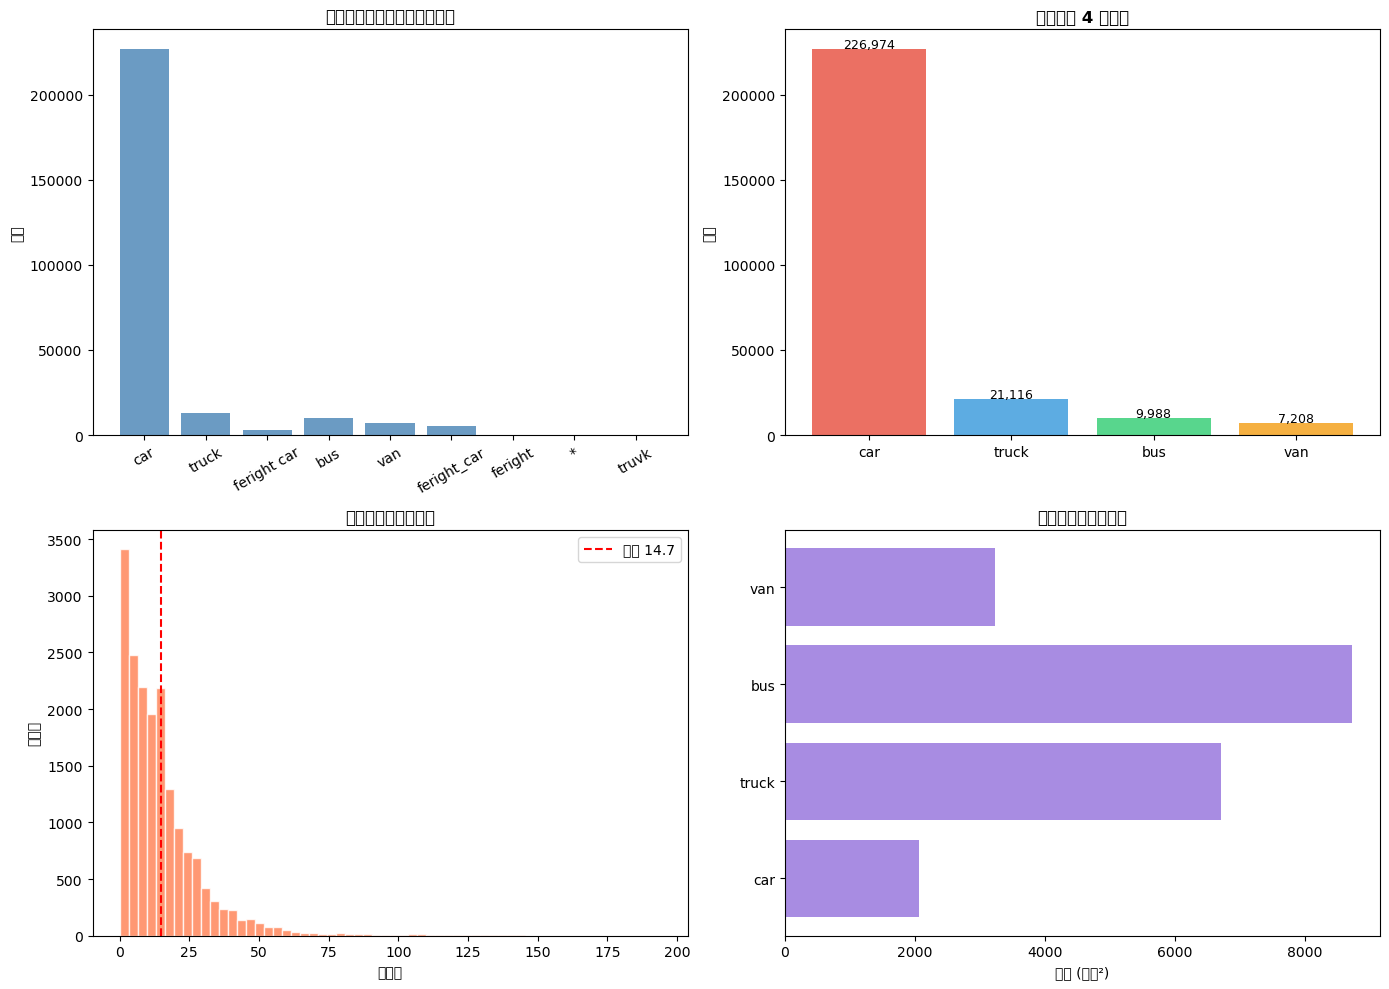

已保存 eda_class_distribution.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cls_raw = list(raw_class_counts.keys())
cnt_raw = list(raw_class_counts.values())
axes[0,0].bar(cls_raw, cnt_raw, color='steelblue', alpha=0.8)
axes[0,0].set_title('Original class distribution (with noisy labels)', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)

cls_norm = list(norm_class_counts.keys())
cnt_norm = list(norm_class_counts.values())
bar_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
axes[0,1].bar(cls_norm, cnt_norm, color=bar_colors, alpha=0.8)
axes[0,1].set_title('Normalized class distribution (4 classes)', fontweight='bold')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(cnt_norm):
    axes[0,1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

axes[1,0].hist(obj_per_image, bins=60, color='coral', alpha=0.8, edgecolor='white')
axes[1,0].axvline(np.mean(obj_per_image), color='red', linestyle='--',
                   label=f'Mean {np.mean(obj_per_image):.1f}')
axes[1,0].set_title('Distribution of Objects per Image', fontweight='bold')
axes[1,0].set_xlabel('Number of Objects'); axes[1,0].set_ylabel('Number of Images')
axes[1,0].legend()

avg_area = {k: np.mean(v) for k, v in area_by_class.items()}
axes[1,1].barh(list(avg_area.keys()), list(avg_area.values()), color='mediumpurple', alpha=0.8)
axes[1,1].set_title('Average Object Area by Class', fontweight='bold')
axes[1,1].set_xlabel('Area (pixels²)')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to eda_class_distribution.png")


In [ ]:
all_areas = [a for areas in area_by_class.values() for a in areas]
small = sum(1 for a in all_areas if a <= 32*32)
print(f"Total number of targets:{len(all_areas):,}")
print(f"Small objects (≤32×32): {small:,}  Proportion {small/len(all_areas)*100:.1f}%")
print(f"Area statistics: min={min(all_areas):.0f}  median={np.median(all_areas):.0f}  "
      f"mean={np.mean(all_areas):.0f}  max={max(all_areas):.0f}")


目标总数：265,286
小目标（≤32×32）：31,576  占比 11.9%
面积统计：min=110  median=1960  mean=2719  max=91008


## Part 4：图像样本可视化（含 BBox 标注）

/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2021588130.py:43: UserWarning: Glyph 26631 (\N{CJK UN

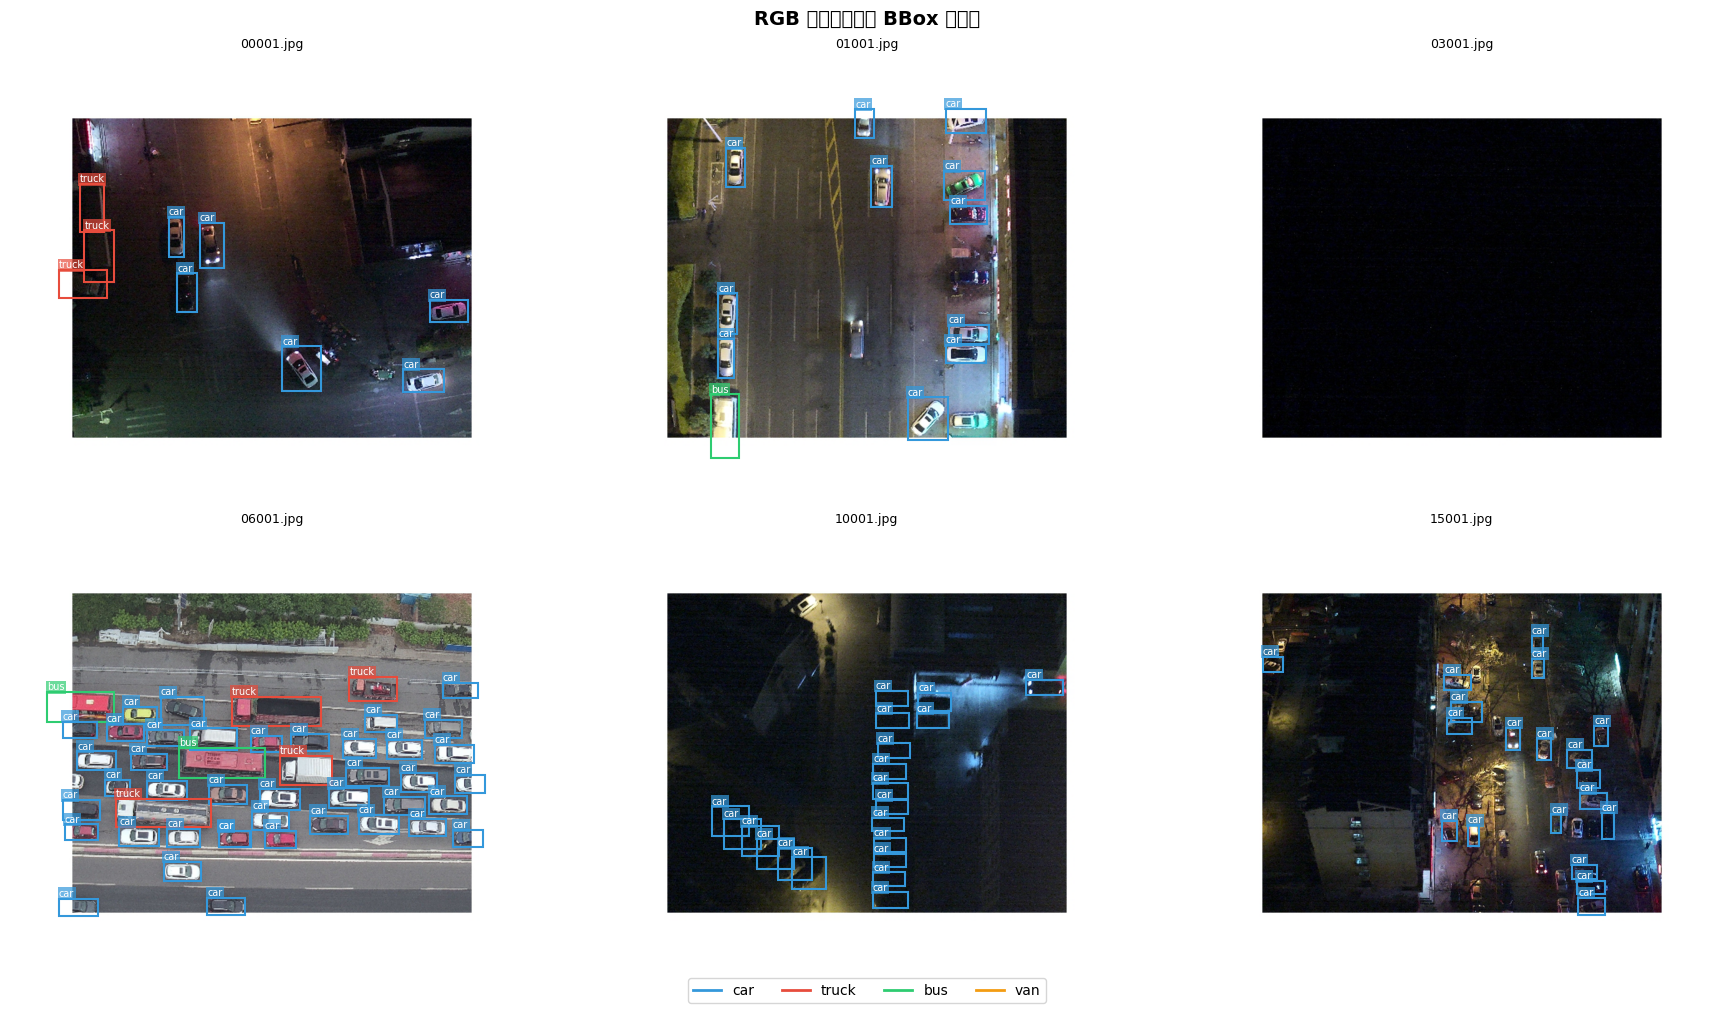

已保存 rgb_samples_with_bbox.png


In [ ]:
CLASS_COLORS = {'car': '#3498db', 'truck': '#e74c3c', 'bus': '#2ecc71', 'van': '#f39c12'}

train_img_dir   = DATASET_ROOT / 'train' / 'trainimg'
train_label_dir = DATASET_ROOT / 'train' / 'trainlabel'
img_files = sorted(train_img_dir.glob('*.jpg'))

sample_indices = [0, 1000, 3000, 6000, 10000, 15000]
sample_files   = [img_files[i] for i in sample_indices if i < len(img_files)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_files):
    img  = Image.open(img_path).convert('RGB')
    anno = parse_xml_annotation(train_label_dir / (img_path.stem + '.xml'))
    ax.imshow(img)

    if anno:
        for obj in anno['objects']:
            norm = CLASS_NORMALIZE.get(obj['class'])
            if norm is None:
                continue
            xmin, ymin, xmax, ymax = obj['bbox']
            color = CLASS_COLORS.get(norm, 'white')
            rect = patches.Rectangle(
                (xmin, ymin), xmax - xmin, ymax - ymin,
                linewidth=1.5, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(xmin, ymin - 3, norm, fontsize=7, color='white',
                    bbox=dict(facecolor=color, alpha=0.7, pad=1, edgecolor='none'))

    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color=c, linewidth=2, label=k)
                  for k, c in CLASS_COLORS.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('RGB Image Samples (with BBox Annotations)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'rgb_samples_with_bbox.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to rgb_samples_with_bbox.png")


## Part 5：基线模型加载与评估

In [ ]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    'baseline_train',
    str(NOTEBOOK_DIR / '55230316_baseline_train.py')
)
train_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(train_mod)

BaselineDetector    = train_mod.BaselineDetector
DroneVehicleDataset = train_mod.DroneVehicleDataset
collate_fn          = train_mod.collate_fn
evaluate_map        = train_mod.evaluate_map
STANDARD_CLASSES    = train_mod.STANDARD_CLASSES
idx_to_class        = {v: k for k, v in STANDARD_CLASSES.items()}

print("✓ The model and evaluation functions have been imported from 55230316_baseline_train.py")


✓ 已从 55230316_baseline_train.py 导入模型和评估函数


设备：cuda


/home/tyr/.conda/envs/tyr/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tyr/.conda/envs/tyr/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ 加载检查点：/home/tyr/ultralytics/checkpoints/baseline/best.pth
  训练 epoch：3
  最佳 mAP：0.2583


/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1389672417.py:26: UserWarning: Glyph 38598 (\N{CJK UN

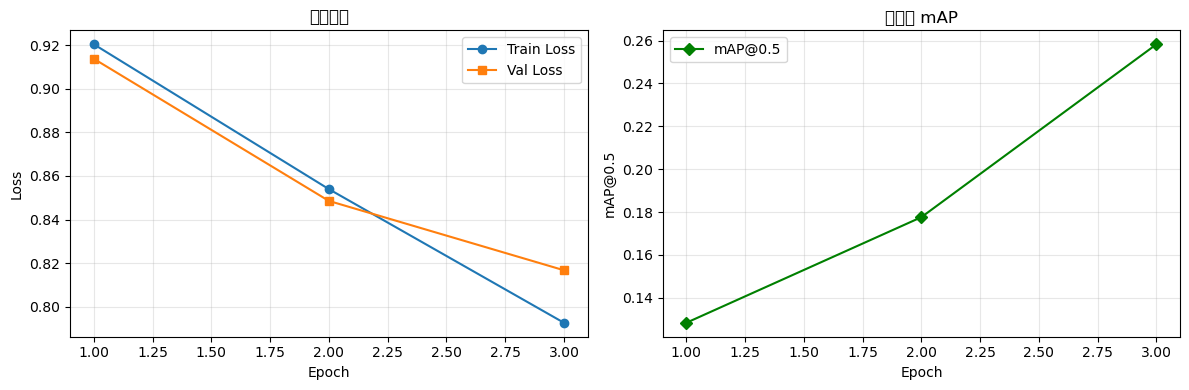

已保存 training_curve.png


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"设备：{device}")

CKPT_PATH = NOTEBOOK_DIR / 'checkpoints' / 'baseline' / 'best.pth'
model = BaselineDetector(num_classes=4).to(device)

if CKPT_PATH.exists():
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt['model'])
    print(f"✓ Loaded checkpoint: {CKPT_PATH}")
    print(f"  Training epoch: {ckpt.get('epoch', '?')}")
    print(f"  Best mAP: {ckpt.get('mAP', 0):.4f}")

    history = ckpt.get('history', {})
    if history:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        epochs = range(1, len(history['train_loss']) + 1)
        axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss')
        axes[0].plot(epochs, history['val_loss'],   's-', label='Val Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)
        if 'mAP' in history:
            axes[1].plot(epochs, history['mAP'], 'D-', color='green', label='mAP@0.5')
            axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('mAP@0.5')
            axes[1].set_title('Validation mAP'); axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(str(FIGURES_DIR / 'training_curve.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved to training_curve.png")
else:
    print(f"⚠ Checkpoint not found: {CKPT_PATH}")
    print("  Please run: python 55230316_baseline_train.py")


mAP@0.5 = 0.2583

  bus     : 0.2008
  car     : 0.6448
  truck   : 0.1875
  van     : 0.0000


/tmp/ipykernel_1906320/1907528777.py:19: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1907528777.py:19: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1907528777.py:19: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/1907528777.py:20: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.savefig(str(FIGURES_DIR / 'class_ap.png'), dpi=150, bbox_inches='tight')
/tmp/ipykernel_1906320/1907528777.py:20: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.savefig(str(FIGURES_DIR / 'class_ap.png'), dpi=150, bbox_inches='tight')
/tmp/ipykernel_1906320/1907528777.py:20: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from fo

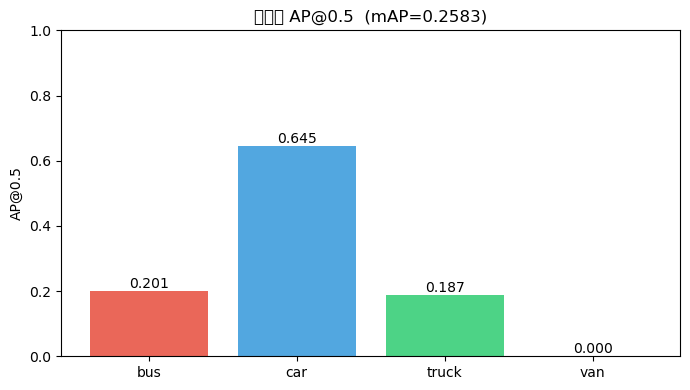

已保存 class_ap.png


In [ ]:
if CKPT_PATH.exists():
    val_ds     = DroneVehicleDataset(DATASET_ROOT, split='val')
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_fn
    )

    mAP, ap_list = evaluate_map(model, val_loader, 4, device)
    print(f"mAP@0.5 = {mAP:.4f}\n")
    for c, ap in enumerate(ap_list):
        print(f"  {idx_to_class[c]:8s}: {ap:.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    cls_names = [idx_to_class[i] for i in range(4)]
    bars = ax.bar(cls_names, ap_list, color=bar_colors, alpha=0.85)
    ax.set_ylabel('AP@0.5'); ax.set_title(f'All categories AP@0.5 (mAP={mAP:.4f})')
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, ap_list):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'class_ap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to class_ap.png")


## Part 6：推理可视化

/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1906320/2216345635.py:50: UserWarning: Glyph 32467 (\N{CJK UN

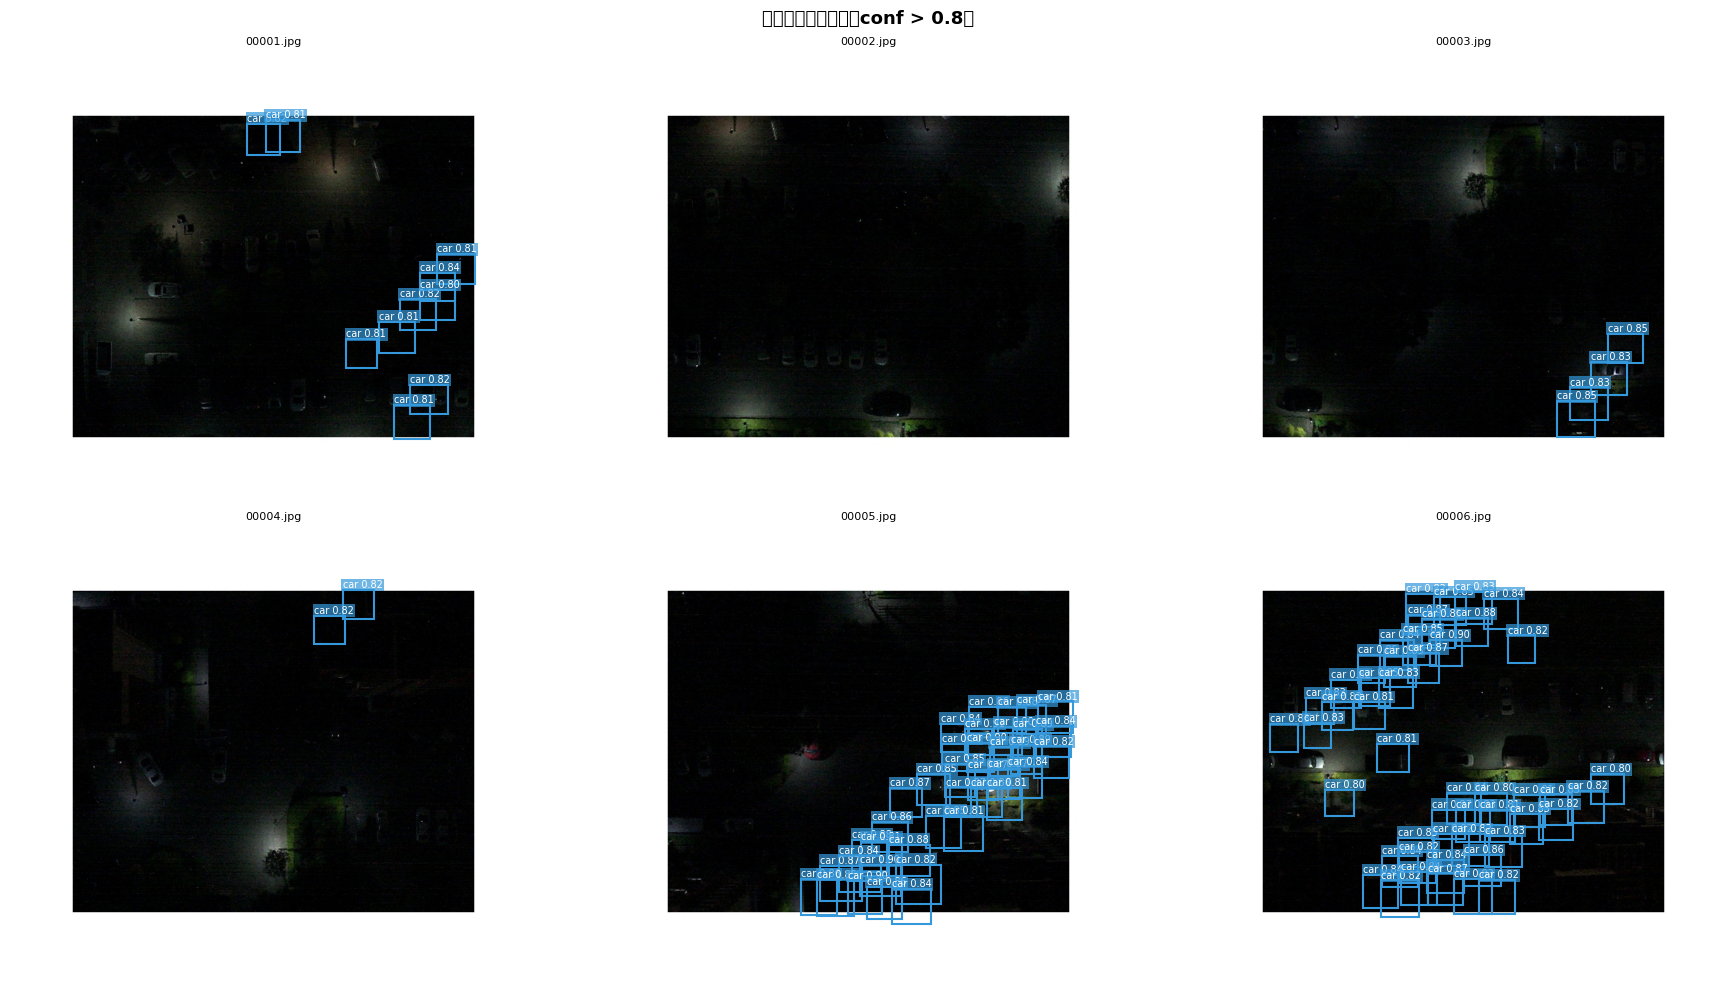

已保存 inference_results.png


In [ ]:
if CKPT_PATH.exists():
    val_ds_vis = DroneVehicleDataset(DATASET_ROOT, split='val')
    vis_loader = torch.utils.data.DataLoader(
        val_ds_vis, batch_size=6, shuffle=False, num_workers=0, collate_fn=collate_fn
    )

    model.eval()
    with torch.no_grad():
        batch = next(iter(vis_loader))
        preds = model(batch['image'].to(device)).cpu()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax_idx, (img_path, pred_b) in enumerate(zip(batch['image_path'], preds)):
        img    = Image.open(img_path).convert('RGB')
        img_np = np.array(img)
        img_h, img_w = img_np.shape[:2]
        ax = axes[ax_idx]
        ax.imshow(img_np)

        for a in range(pred_b.size(0)):
            pa     = pred_b[a]
            conf   = torch.sigmoid(pa[4])
            cls_sc = torch.softmax(pa[5:], dim=0)
            score  = conf * cls_sc.max(0).values
            cls_id = cls_sc.argmax(0)

            for i in (score > 0.8).nonzero(as_tuple=True)[0]:
                cx = pa[0,i].item(); cy = pa[1,i].item()
                w  = pa[2,i].item(); h  = pa[3,i].item()
                if w < 0.01 or h < 0.01:
                    continue
                c    = int(cls_id[i].item())
                name = idx_to_class.get(c, f'cls{c}')
                col  = CLASS_COLORS.get(name, 'white')
                x1   = (cx - w/2) * img_w
                y1   = (cy - h/2) * img_h
                ax.add_patch(patches.Rectangle(
                    (x1, y1), w*img_w, h*img_h,
                    linewidth=1.5, edgecolor=col, facecolor='none'
                ))
                ax.text(x1, y1-3, f'{name} {score[i]:.2f}', fontsize=7, color='white',
                        bbox=dict(facecolor=col, alpha=0.7, pad=1, edgecolor='none'))

        ax.set_title(Path(img_path).name, fontsize=8)
        ax.axis('off')

    plt.suptitle('Baseline model inference result (with confidence > 0.8)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'inference_results.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to inference_results.png")


## 总结

| 项目 | 内容 |
|------|------|
| 数据集 | DroneVehicle（RGB，840×712） |
| 训练集 | 17,990 张 |
| 验证集 | 1,469 张 |
| 类别 | bus / car / truck / van（4 类） |
| 模型 | ResNet18 + 单尺度检测头（3 anchors） |
| 输入 | RGB 3 通道，resize 640×640 |
| 基线 mAP@0.5 | 见上方评估结果 |

> 本基线作为后续 YOLO11-CBAM 改进模型的对比基准。
